In [1]:
from lsst.daf.butler import Butler
import astropy
import numpy as np
import lsst.afw.display as afwDisplay
import os
import pandas as pd
import lsst.geom as geom
import lsst.afw.image as afwImage
import gc
import time
import pandas as pd
import getpass

import lsst.geom
import re
import multiprocessing

In [2]:
import matplotlib.pyplot as plt


In [3]:
from lsst.ctrl.mpexec import SimplePipelineExecutor
from lsst.pipe.base import Pipeline

In [4]:
butler = Butler("/repo/DP1", collections="LSSTComCam/DP1")
assert butler is not None

In [4]:
ref_deepcoadd = butler.query_datasets("deep_coadd",
                     where="tract = 4848 AND band = 'r'")

In [5]:
len(ref_deepcoadd)

12

In [6]:
for rr in range(len(ref_deepcoadd)):
    print(rr)
    my_deepCoadd = butler.get(ref_deepcoadd[rr])
    my_coadd_inputs = my_deepCoadd.getInfo().getCoaddInputs()
    print("total", len(my_coadd_inputs.visits))

0
total 11
1
total 112
2
total 69
3
total 24
4
total 221
5
total 171
6
total 82
7
total 13
8
total 236
9
total 217
10
total 117
11
total 32


In [7]:
ref = 8
my_deepCoadd = butler.get(ref_deepcoadd[ref])
my_coadd_inputs = my_deepCoadd.getInfo().getCoaddInputs()
print("total", len(my_coadd_inputs.visits))

total 236


In [8]:
my_tract = ref_deepcoadd[ref].dataId['tract']
my_patch = ref_deepcoadd[ref].dataId['patch']
my_band = ref_deepcoadd[ref].dataId['band']

In [9]:
visitTableRef = list(butler.registry.queryDatasets('visit_table'))
len(visitTableRef)

1

In [10]:
visitTable = butler.get(visitTableRef[0]).to_pandas()
visitTable = visitTable.set_index('visitId')

In [11]:
my_coadd_visits_mjds = visitTable.loc[my_coadd_inputs.visits['id']]['expMidptMJD']

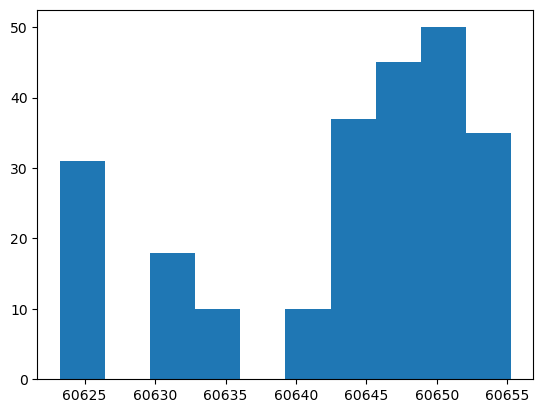

In [12]:
plt.hist(my_coadd_visits_mjds);

In [14]:
np.unique(round(my_coadd_visits_mjds,0))

array([60623., 60626., 60630., 60631., 60632., 60634., 60635., 60642.,
       60643., 60644., 60645., 60646., 60648., 60650., 60651., 60652.,
       60653., 60654., 60655.])

In [15]:
Window1_start = my_coadd_visits_mjds.values[0]
Window1_end = Window1_start+10

In [16]:
my_range = np.array((my_coadd_visits_mjds > Window1_start)
                    & (my_coadd_visits_mjds < Window1_end))
my_visits = my_coadd_inputs.visits[my_range]

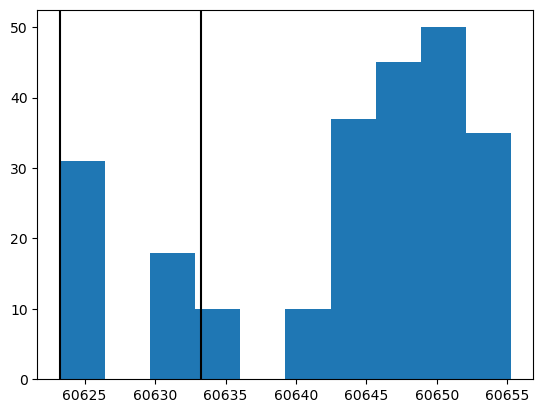

In [19]:
plt.hist(my_coadd_visits_mjds);
plt.axvline(Window1_start, c='k')
plt.axvline(Window1_end, c='k')

In [20]:
len(my_visits)

48

In [22]:
my_visits_tupleString = "("+",".join(my_visits['id'].astype(str))+")"
query_string = """tract = {} AND patch = {} AND band = {}, visit IN {} AND skymap = 'lsst_cells_v1'
                """.format(my_tract, my_patch, my_band, my_visits_tupleString)
print(query_string)

tract = 4848 AND patch = 90 AND band = r, visit IN (2024110800247,2024110800250,2024110800251,2024110800254,2024110800255,2024110800258,2024110800259,2024110800262,2024110800263,2024110800272,2024110800273,2024110800278,2024110800281,2024110800282,2024110800287,2024110800288,2024110800299,2024110800305,2024110800306,2024110800311,2024110800312,2024111100075,2024111100080,2024111100082,2024111100083,2024111100086,2024111100087,2024111100090,2024111100091,2024111100094,2024111500238,2024111600110,2024111600115,2024111600116,2024111600293,2024111600294,2024111600295,2024111600296,2024111600297,2024111700126,2024111700127,2024111700128,2024111700129,2024111700130,2024111700154,2024111700155,2024111700157,2024111700158) AND skymap = 'lsst_cells_v1'
                


In [23]:
my_username = getpass.getuser()
print(my_username)

taceroc


In [26]:
# my_collection_identifier = 'custom_coadd_window1_test2_2_v1'
my_collection_identifier = f'custom_coadd_window1_{int(round(Window1_start,0))}-{int(round(Window1_end,0))}-{my_tract}-{my_patch}-{my_band}'
print(my_collection_identifier)

custom_coadd_window1_60623-60633-4848-90-r


In [27]:
my_outputCollection = 'u/'+my_username+'/'+'dp1'+'/'+my_collection_identifier

# taceroc/taceroc_seagull_coadd_LE/test_dp1_env
print('Name of new butler collection for my output: ', my_outputCollection)

Name of new butler collection for my output:  u/taceroc/dp1/custom_coadd_window1_60623-60633-4848-90-r


# second window

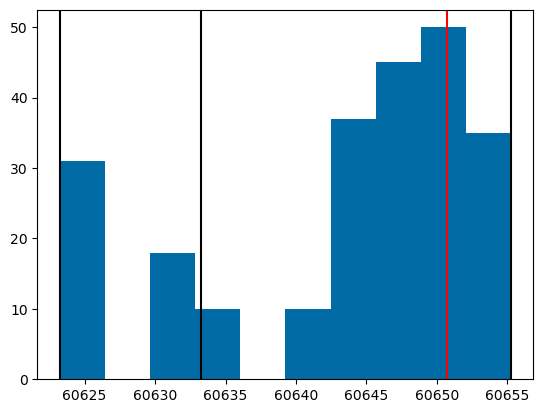

In [54]:
Window2_start = my_coadd_visits_mjds.values[-1]-4.5
Window2_end = Window2_start+4.5

my_range = np.array((my_coadd_visits_mjds > Window2_start)
                    & (my_coadd_visits_mjds < Window2_end))
my_visits = my_coadd_inputs.visits[my_range]


plt.hist(my_coadd_visits_mjds);
plt.axvline(Window1_start, c='k')
plt.axvline(Window1_end, c='k')
plt.axvline(Window2_start, c='r')
plt.axvline(Window2_end, c='k')

In [55]:
len(my_visits)

59

In [56]:
my_visits_tupleString = "("+",".join(my_visits['id'].astype(str))+")"
query_string = """tract = {} AND patch = {} AND band = {}, visit IN {} AND skymap = 'lsst_cells_v1'
                """.format(my_tract, my_patch, my_band, my_visits_tupleString)
print(query_string)

tract = 4848 AND patch = 90 AND band = r, visit IN (2024120600070,2024120600071,2024120600072,2024120600073,2024120600074,2024120600095,2024120600096,2024120600097,2024120600098,2024120600099,2024120600239,2024120600240,2024120600241,2024120600242,2024120600243,2024120600264,2024120600265,2024120600266,2024120600267,2024120600268,2024120600272,2024120600273,2024120600274,2024120600275,2024120600276,2024120700294,2024120700295,2024120700296,2024120700297,2024120700298,2024120700299,2024120700300,2024120700301,2024120700302,2024120700303,2024120800345,2024120800346,2024120800347,2024120800348,2024120800349,2024120900309,2024120900310,2024120900311,2024120900312,2024120900313,2024121000402,2024121000403,2024121000404,2024121000405,2024121000406,2024121000417,2024121000418,2024121000419,2024121000420,2024121000421,2024121000422,2024121000423,2024121000424,2024121000425) AND skymap = 'lsst_cells_v1'
                


In [57]:
my_collection_identifier = f'custom_coadd_window2_{int(round(Window2_start,0))}-{int(round(Window2_end,0))}-{my_tract}-{my_patch}-{my_band}'
print(my_collection_identifier)

custom_coadd_window2_60651-60655-4848-90-r


In [58]:
my_outputCollection = 'u/'+my_username+'/'+'dp1'+'/'+my_collection_identifier

# taceroc/taceroc_seagull_coadd_LE/test_dp1_env
print('Name of new butler collection for my output: ', my_outputCollection)

Name of new butler collection for my output:  u/taceroc/dp1/custom_coadd_window2_60651-60655-4848-90-r


In [29]:
drp_yaml_file = "$DRP_PIPE_DIR/pipelines/LSSTComCam/DRP-v2-compat.yaml"
uri = drp_yaml_file + "#makeDirectWarp,assembleDeepCoadd,makePsfMatchedWarp,selectDeepCoaddVisits"
# pipeline = Pipeline.from_uri(uri)

In [ ]:
#!/bin/bash                                                                                                                                     
#SBATCH --account=dessn
#SBATCH --time=24:00:00
#SBATCH --qos=shared
#SBATCH --nodes=1
#SBATCH --constraint=cpu
#SBATCH --cpus-per-task=32
#SBATCH --output=dp1_step1step2-%j.out


export STACKCVMFS=/cvmfs/sw.lsst.eu/almalinux-x86_64/lsst_distrib
export LSST_STACK_VERSION=v29.1.1

module load cpu

source $STACKCVMFS/$LSST_STACK_VERSION/loadLSST-ext.bash
setup -t v29_1_1 lsst_distrib


export DAF_BUTLER_REPOSITORY_INDEX=/global/cfs/cdirs/lsst/production/gen3/shared/data-repos.yaml

export OMP_NUM_THREADS=1


# make the custom coadd QuantumGraph visualization
pipetask build \
-p $DRP_PIPE_DIR/pipelines/LSSTComCam/DRP-v2-compat.yaml#makeDirectWarp,assembleDeepCoadd,makePsfMatchedWarp,selectDeepCoaddVisits \
--pipeline-dot pipeline.dot; \
dot pipeline.dot -Tpdf > dp1_step1step2.pdf

# remove temporary file
rm pipeline.dot 

# specify the directory for output log files
LOGDIR=logs

# make the directory for output log files
mkdir $LOGDIR

# run the custom coaddition
LOGFILE=$LOGDIR/step1step2-logfile.log; \
date | tee $LOGFILE; \
pipetask --long-log --log-file $LOGFILE run \
-b /repo/DP1 \
-i LSSTComCam/DP1 \
-o u/taceroc/dp1/custom_coadd_window1_60623-60633-t4848-p90-r \
-p $DRP_PIPE_DIR/pipelines/LSSTComCam/DRP-v2-compat.yaml#makeDirectWarp,assembleDeepCoadd,makePsfMatchedWarp,selectDeepCoaddVisits \
-c makeDirectWarp:useVisitSummaryPsf=False \
-c makeDirectWarp:useVisitSummaryPhotoCalib=False \
-c makeDirectWarp:useVisitSummaryWcs=False \
-c makeDirectWarp:connections.calexp_list="visit_image" \
-d "tract=4848 AND patch=90 AND band=r AND visit IN (2024110800247,2024110800250,2024110800251,2024110800254,2024110800255,2024110800258,2024110800259,2024110800262,2024110800263,2024110800272,2024110800273,2024110800278,2024110800281,2024110800282,2024110800287,2024110800288,2024110800299,2024110800305,2024110800306,2024110800311,2024110800312,2024111100075,2024111100080,2024111100082,2024111100083,2024111100086,2024111100087,2024111100090,2024111100091,2024111100094,2024111500238,2024111600110,2024111600115,2024111600116,2024111600293,2024111600294,2024111600295,2024111600296,2024111600297,2024111700126,2024111700127,2024111700128,2024111700129,2024111700130,2024111700154,2024111700155,2024111700157,2024111700158) AND skymap='lsst_cells_v1'"; \
date | tee -a $LOGFILE

In [14]:
butler_output = Butler("/repo/DP1", collections="u/taceroc/dp1/custom_coadd_window1_60623-60633-t4848-p90-r")

In [15]:
deep_coadd_ref = list(butler_output.registry.queryDatasets('deep_coadd_predetection'))


In [16]:
len(deep_coadd_ref)

1

In [17]:
afwDisplay.setDefaultBackend('matplotlib')
plt.style.use('tableau-colorblind10')

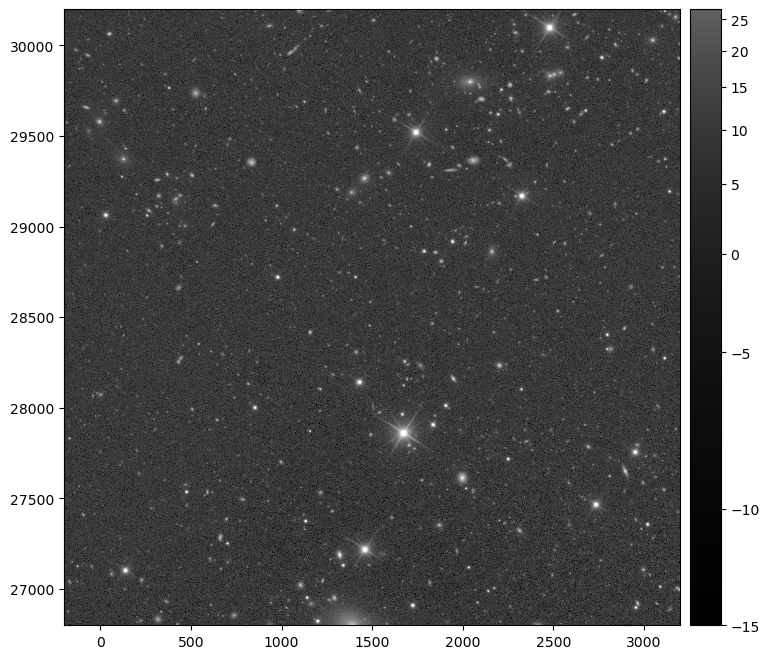

In [18]:
deepCoadd = butler_output.get(deep_coadd_ref[0])
fig = plt.figure(figsize=(10, 8))
afw_display = afwDisplay.Display(frame=fig)
afw_display.scale('asinh', 'zscale')
afw_display.mtv(deepCoadd.image)
plt.gca().axis('on')
plt.show()

In [21]:
butler_output = Butler("/repo/DP1", collections="u/taceroc/dp1/custom_coadd_window2_60651-60655-4848-90-r")
deep_coadd_ref = list(butler_output.registry.queryDatasets('deep_coadd_predetection'))


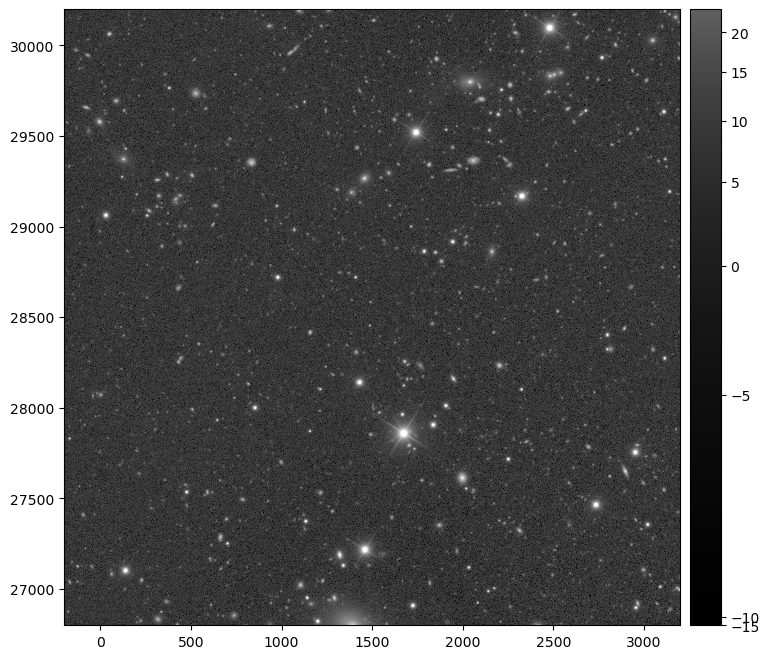

In [22]:
deepCoadd = butler_output.get(deep_coadd_ref[0])
fig = plt.figure(figsize=(10, 8))
afw_display = afwDisplay.Display(frame=fig)
afw_display.scale('asinh', 'zscale')
afw_display.mtv(deepCoadd.image)
plt.gca().axis('on')
plt.show()

In [24]:
f"{deep_coadd_ref[0].dataId['tract']}_{deep_coadd_ref[0].dataId['patch']}_{deep_coadd_ref[0].dataId['band']}_dp1"

'4848_90_r_dp1'